# GHG Emissons for Nova Scotia After Cleaning
## Cleaning Steps
## Trends
### Top Emission Sectors

In [1]:
#ghg_sector_ns_clean.csv

import pandas as pd

# Load dataset
df = pd.read_csv("ghg_sector_ns_clean.csv")


df.head()

,Year,Sectors,Emissions
0,2013,Accommodation and food services [BS72000],59
1,2013,Administrative and support services [BS56100],34
2,2013,"Advertising, promotion, meals, entertainment, ...",0
3,2013,"Advertising, public relations and related serv...",1
4,2013,Aerospace product and parts manufacturing [BS3...,8


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       1218 non-null   int64 
 1   Sectors    1218 non-null   object
 2   Emissions  1218 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 28.7+ KB


In [3]:
df.sample(5)

,Year,Sectors,Emissions
849,2020,Nursing and residential care facilities [GS62300],3
390,2016,Non-metallic mineral product manufacturing (ex...,5
119,2014,Balancing item: Motor fuels,-229
967,2021,Other federal government services [GS91100],218
382,2016,Miscellaneous chemical product manufacturing [...,1


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1218, 3)


In [5]:
print(df.columns)

Index(['Year', 'Sectors', 'Emissions'], dtype='object')


In [7]:
df.describe()

,Year,Emissions
count,1218.000000,1218.000000
mean,2017.951560,140.163383
std,3.131485,682.615207
min,2013.000000,-1918.000000
25%,2015.000000,2.000000
50%,2018.000000,11.000000
75%,2021.000000,51.000000
max,2023.000000,7224.000000


In [8]:
df["Sectors"] = df["Sectors"].str.replace(r"\[.*?\]", "", regex=True).str.strip()

In [9]:
df["Sectors"].head(20)

0                       Accommodation and food services
1                   Administrative and support services
2     Advertising, promotion, meals, entertainment, ...
3     Advertising, public relations and related serv...
4             Aerospace product and parts manufacturing
5                                    Air transportation
6                             Animal food manufacturing
7                    Arts, entertainment and recreation
8                              Balancing item: Aviation
9                               Balancing item: Biomass
10                          Balancing item: Motor fuels
11    Balancing item: Non-energy Products from Fuels...
12                    Balancing item: Other differences
13          Balancing item: Synthetic fluorinated gases
14                                Balancing item: Waste
15                         Basic chemical manufacturing
16                                            Breweries
17            Cement and concrete product manufa

In [10]:
df["Sectors"].unique()

array(['Accommodation and food services',
       'Administrative and support services',
       'Advertising, promotion, meals, entertainment, and travel',
       'Advertising, public relations and related services',
       'Aerospace product and parts manufacturing', 'Air transportation',
       'Animal food manufacturing', 'Arts, entertainment and recreation',
       'Balancing item: Aviation', 'Balancing item: Biomass',
       'Balancing item: Motor fuels',
       'Balancing item: Non-energy Products from Fuels and Solvent Use',
       'Balancing item: Other differences',
       'Balancing item: Synthetic fluorinated gases',
       'Balancing item: Waste', 'Basic chemical manufacturing',
       'Breweries', 'Cement and concrete product manufacturing',
       'Clothing and leather and allied product manufacturing',
       'Coal mining', 'Communication engineering construction',
       'Computer systems design and other professional, scientific and technical services',
       'Converte

In [13]:
df.to_csv("ghg_sector_ns_clean2.csv", index=False)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       1218 non-null   int64 
 1   Sectors    1218 non-null   object
 2   Emissions  1218 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 28.7+ KB


In [20]:
# ============================================
# NOVA SCOTIA GHG EMISSIONS VISUALIZATIONS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ghg_sector_ns_clean2.csv")

# Preview dataset
print(df.head(20))



    Year                                            Sectors  Emissions
0   2013                    Accommodation and food services         59
1   2013                Administrative and support services         34
2   2013  Advertising, promotion, meals, entertainment, ...          0
3   2013  Advertising, public relations and related serv...          1
4   2013          Aerospace product and parts manufacturing          8
5   2013                                 Air transportation        381
6   2013                          Animal food manufacturing          8
7   2013                 Arts, entertainment and recreation          2
8   2013                           Balancing item: Aviation       -241
9   2013                            Balancing item: Biomass      -1528
10  2013                        Balancing item: Motor fuels       -250
11  2013  Balancing item: Non-energy Products from Fuels...        103
12  2013                  Balancing item: Other differences        671
13  20

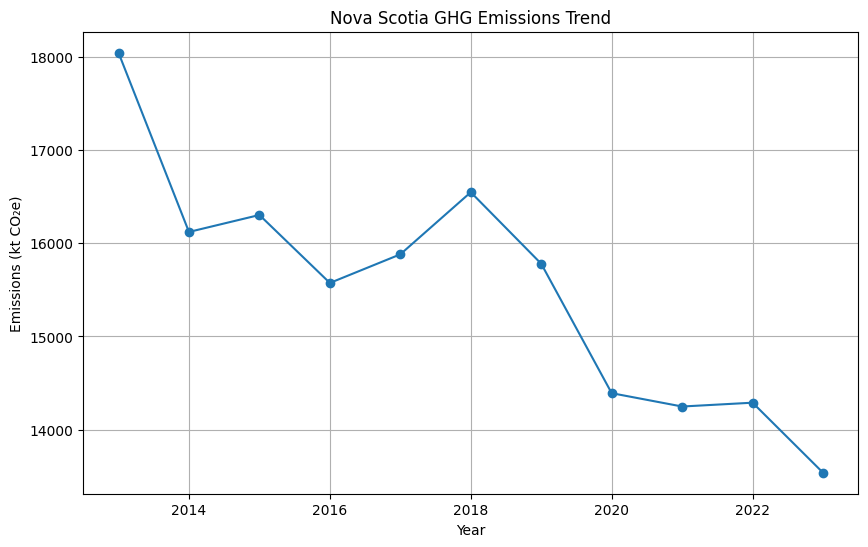

In [21]:
# ============================================
# 1. NS GHG EMISSIONS TREND OVER TIME
# ============================================

# Group yearly emissions
yearly = df.groupby("Year")["Emissions"].sum()

# Plot
plt.figure(figsize=(10,6))
plt.plot(yearly.index, yearly.values, marker='o')

plt.title("Nova Scotia GHG Emissions Trend")
plt.xlabel("Year")
plt.ylabel("Emissions (kt CO₂e)")

plt.grid(True)
plt.show()



In [23]:
ns_yearly = df.groupby("Year")["Emissions"].sum()

old = ns_yearly.iloc[0]
new = ns_yearly.iloc[-1]

change_pct = (new - old) / old * 100

print(f"NS GHG Change %: {change_pct:.2f}%")

NS GHG Change %: -24.96%


In [25]:
top5 = sector_totals.head(5)
print(top5)

Sectors
Electric power generation, transmission and distribution    69020
Households: Motor fuels and lubricants                      27408
Households: Electricity and other fuels                     19752
Pulp, paper and paperboard mills                             6338
Balancing item: Waste                                        6002
Name: Emissions, dtype: int64


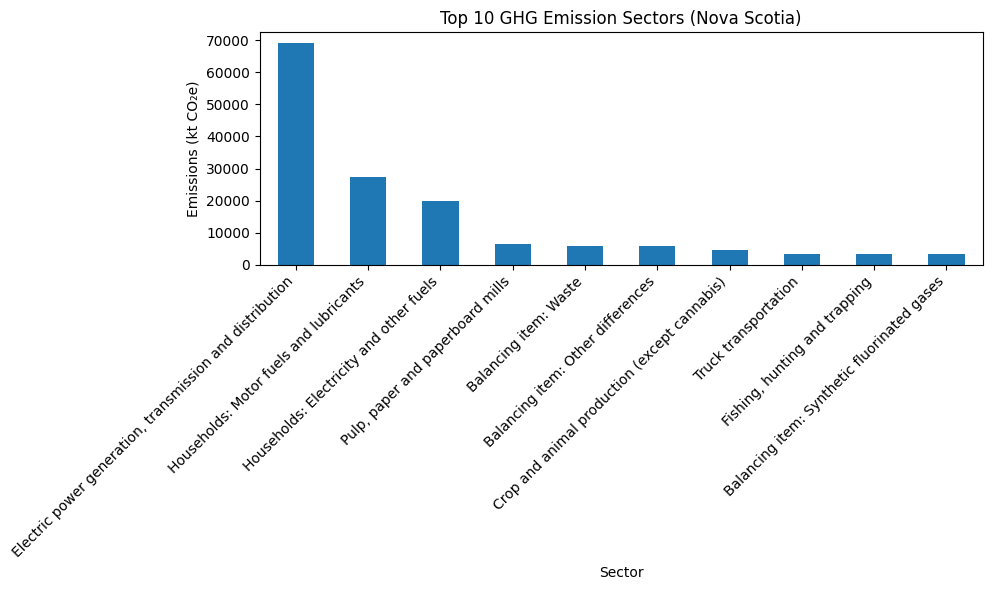

In [35]:
#Bar chart showing Top 10 GHG Emission sectors
top_n = 10
sector_totals = df.groupby("Sectors")["Emissions"].sum().sort_values(ascending=False).head(top_n)

plt.figure(figsize=(10,6))
sector_totals.plot(kind='bar')

plt.title("Top 10 GHG Emission Sectors (Nova Scotia)")
plt.xlabel("Sector")
plt.ylabel("Emissions (kt CO₂e)")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

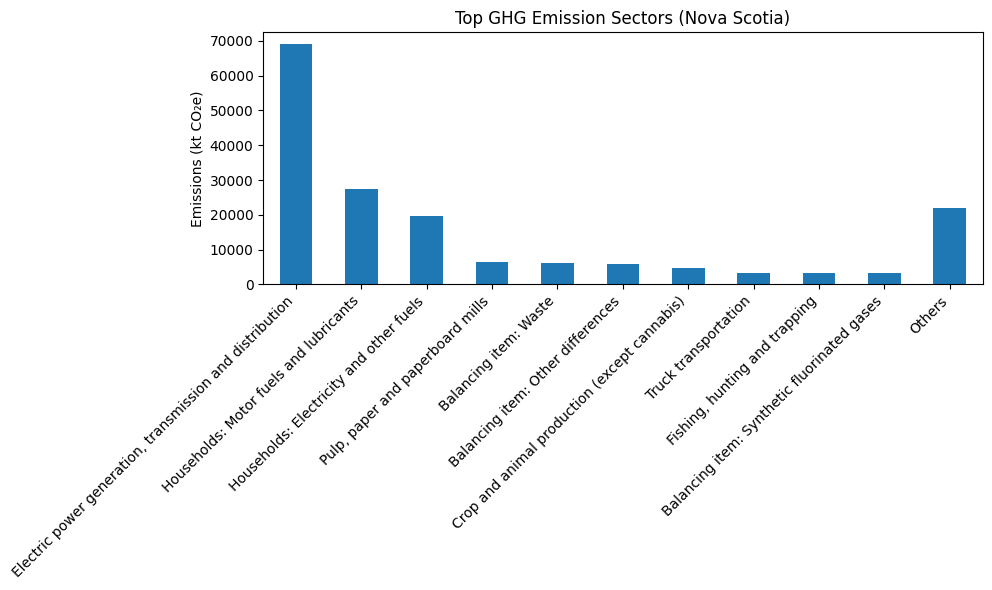

In [39]:
#Bar chart showing Top 10 GHG Emission sectors and “Others”

sector_totals = df.groupby("Sectors")["Emissions"].sum().sort_values(ascending=False)

top10 = sector_totals.head(10)
others = pd.Series({"Others": sector_totals.iloc[10:].sum()})

final = pd.concat([top10, others])

plt.figure(figsize=(10,6))
final.plot(kind='bar')

plt.title("Top GHG Emission Sectors (Nova Scotia)")
plt.ylabel("Emissions (kt CO₂e)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

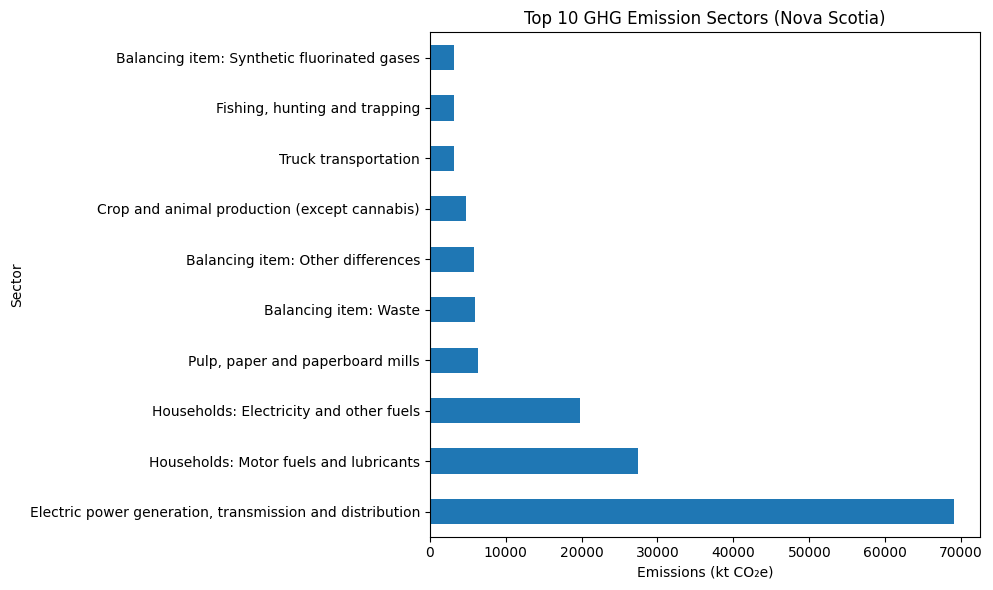

In [36]:
#Horizontal bar chart showing Top GHG Emission 10 sectors only

sector_totals = df.groupby("Sectors")["Emissions"].sum().sort_values(ascending=False)

top10 = sector_totals.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh')

plt.title("Top 10 GHG Emission Sectors (Nova Scotia)")
plt.xlabel("Emissions (kt CO₂e)")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

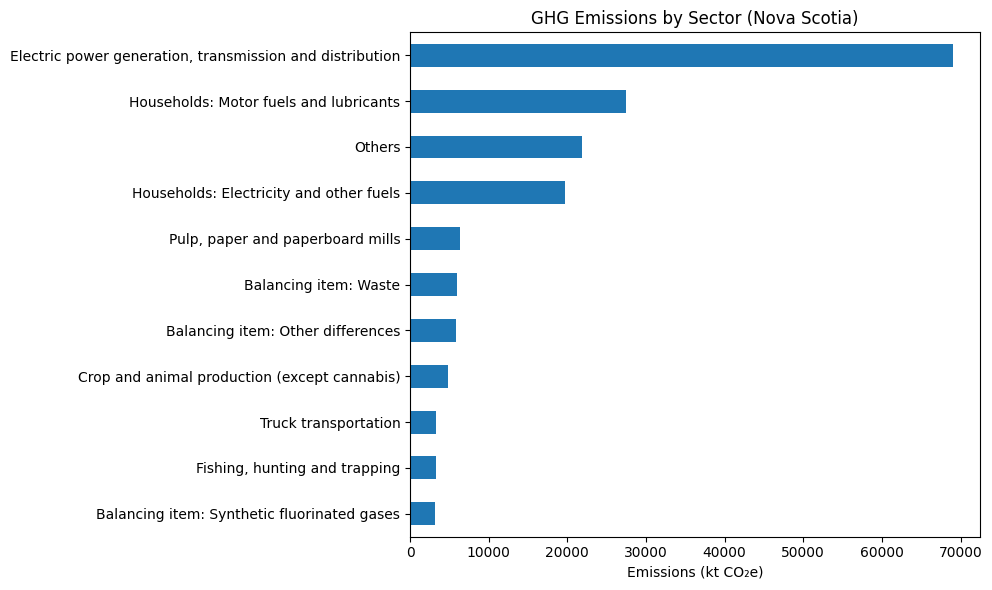

In [38]:
#Horizontal bar chart showing Top 10 sectors and “Others”

top10 = sector_totals.head(10)
others = pd.Series({"Others": sector_totals.iloc[10:].sum()})

final = pd.concat([top10, others])

plt.figure(figsize=(10,6))
final.sort_values().plot(kind='barh')

plt.title("GHG Emissions by Sector (Nova Scotia)")
plt.xlabel("Emissions (kt CO₂e)")

plt.tight_layout()
plt.show()